# Titanic Dataset: Exploratory Data Analysis (EDA)
This notebook performs data cleaning and exploratory data analysis on the Titanic dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Load Data
file_path = r"c:\DS-prodigy-Task-1\data-science-datasets-main\Task 2\train.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nMissing values before cleaning:")
print(df.isnull().sum())
df.head()

Dataset shape: (891, 12)

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning
We drop the 'Cabin' column due to a high number of missing values. We fill missing 'Age' values with the median and 'Embarked' with the mode.

In [3]:
# Drop 'Cabin' because it has too many missing values
df = df.drop(columns=['Cabin'])

# Fill missing 'Age' values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' values with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Exploratory Data Analysis & Visualizations

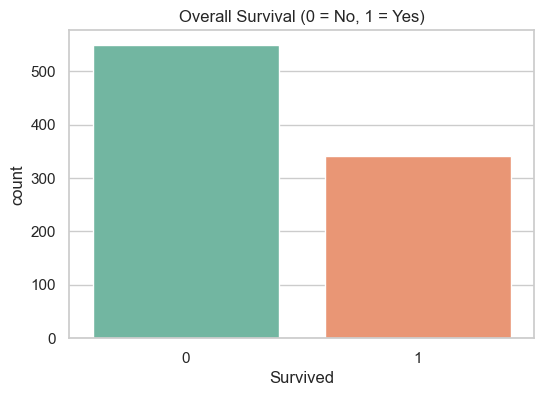

In [4]:
# Overall Survival
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='Set2', hue='Survived', legend=False)
plt.title('Overall Survival (0 = No, 1 = Yes)')
plt.show()

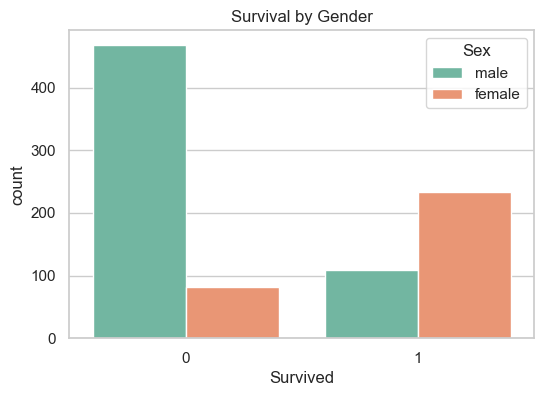

In [5]:
# Survival by Gender
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.show()

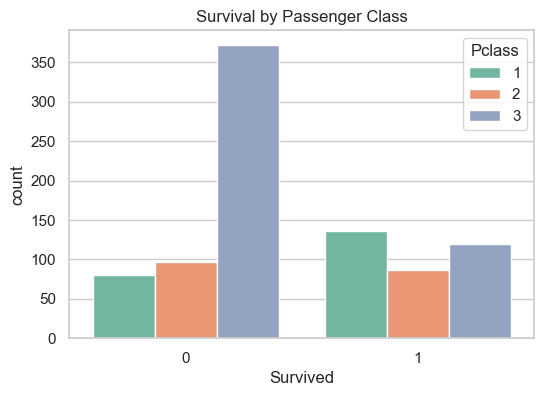

In [6]:
# Survival by Passenger Class
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set2')
plt.title('Survival by Passenger Class')
plt.show()

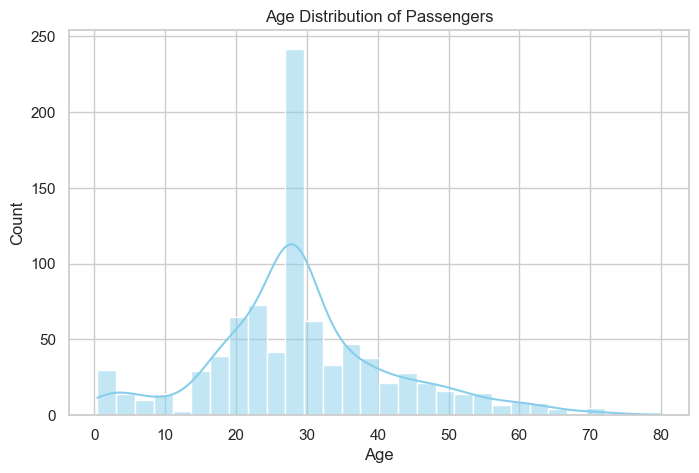

In [7]:
# Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.show()

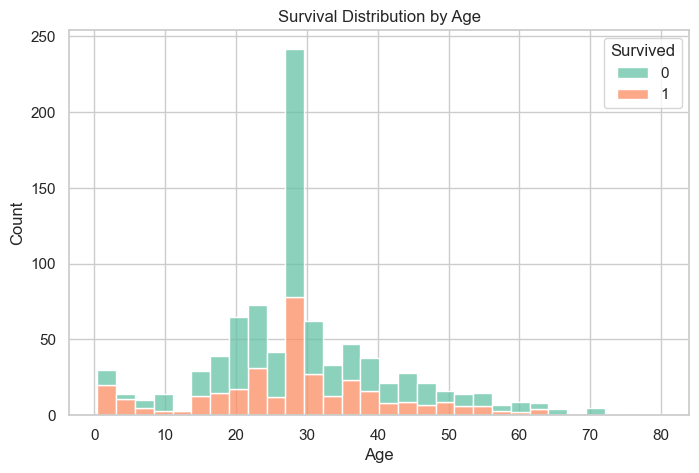

In [8]:
# Survival by Age
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30, palette='Set2')
plt.title('Survival Distribution by Age')
plt.xlabel('Age')
plt.show()

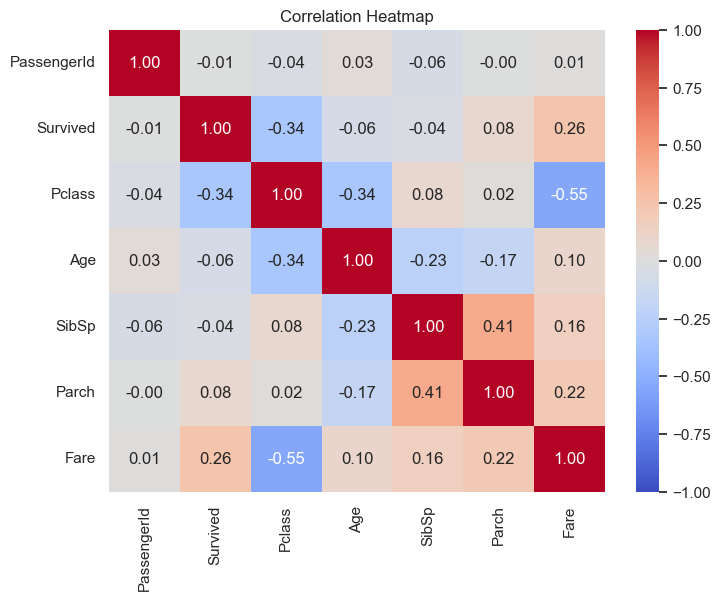

In [9]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()